## importing all the libs 

In [111]:
import pandas as pd
import numpy as np 
import torch
import torch.nn as nn 
from torch.utils.data import Dataset, DataLoader

### lets load the csv first 

In [112]:
data = pd.read_csv('/home/pranav/Epoch/Learning phase 1/ranking_dataset.csv')
data

,val_0,val_1,val_2,val_3,val_4,val_5,val_6,val_7,val_8,val_9,rank_0,rank_1,rank_2,rank_3,rank_4,rank_5,rank_6,rank_7,rank_8,rank_9
0,542,67,876,414,26,335,620,924,950,113,5,1,7,4,0,3,6,8,9,2
1,378,14,210,954,231,572,315,295,567,706,5,0,1,9,2,7,4,3,6,8
2,749,876,73,111,899,213,541,769,287,219,6,8,0,1,9,2,5,7,4,3
3,372,880,475,329,733,564,739,376,632,10,2,9,4,1,7,5,8,3,6,0
4,186,822,577,519,707,123,143,294,693,677,2,9,5,4,8,0,1,3,7,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,930,260,396,754,449,382,145,246,537,518,9,2,4,8,5,3,0,1,7,6
9996,315,847,156,752,280,956,218,727,620,217,4,8,0,7,3,9,2,6,5,1
9997,449,552,620,136,610,69,717,589,851,886,2,3,6,1,5,0,7,4,8,9
9998,491,746,689,385,87,209,856,974,397,312,5,7,6,3,0,1,8,9,4,2


### lets check the data 

In [113]:
print(data.isnull().sum()) #so all the cells have some value


val_0     0
val_1     0
val_2     0
val_3     0
val_4     0
val_5     0
val_6     0
val_7     0
val_8     0
val_9     0
rank_0    0
rank_1    0
rank_2    0
rank_3    0
rank_4    0
rank_5    0
rank_6    0
rank_7    0
rank_8    0
rank_9    0
dtype: int64


### split the training and testing data 

In [114]:
#import train_test_split function 
from sklearn.model_selection import train_test_split

# the test_size is kept 30% of the data and made it to give a fixed random state 
train_df , test_and_validation_df = train_test_split(data , test_size= 0.3 , random_state= 42)

#we will separate a validation data and a test data so that validation can be used to check if the model is overfitting and test is used to 
#generally test the final model 
test_df , validation_df = train_test_split(test_and_validation_df,test_size=0.5,random_state=45) #just putting a different random state although does not matter 
print(train_df)

      val_0  val_1  val_2  val_3  val_4  val_5  val_6  val_7  val_8  val_9  \
9069    532    666    167    227    160    947    923     73    652    155   
2603    216    565    802    246    591    885    534    539    639    788   
7738     79    798    720    223    434    698    579    700    456    856   
1579     19    422    508    661    640    611    382    980    443     18   
5058    303    185    407    307    312     30    220     71    635    968   
...     ...    ...    ...    ...    ...    ...    ...    ...    ...    ...   
5734    289     92    598    260    939    235    975    682     52    177   
5191    430     51    971    822     32    690    506    214     38    390   
5390    576    856    897    210    331    438    735    231    611    390   
860     528    222    367    941    201    151    534    864    995    797   
7270    807    632    578    534      2    201    149    594    175    990   

      rank_0  rank_1  rank_2  rank_3  rank_4  rank_5  rank_6  r

### split the data by values and ranks 

In [115]:
#do label based slicing using 'loc'
train_values = train_df.loc[:,'val_0':'val_9']
test_values = test_df.loc[:,'val_0':'val_9']
valid_values = validation_df.loc[:,'val_0':'val_9']
train_values

,val_0,val_1,val_2,val_3,val_4,val_5,val_6,val_7,val_8,val_9
9069,532,666,167,227,160,947,923,73,652,155
2603,216,565,802,246,591,885,534,539,639,788
7738,79,798,720,223,434,698,579,700,456,856
1579,19,422,508,661,640,611,382,980,443,18
5058,303,185,407,307,312,30,220,71,635,968
...,...,...,...,...,...,...,...,...,...,...
5734,289,92,598,260,939,235,975,682,52,177
5191,430,51,971,822,32,690,506,214,38,390
5390,576,856,897,210,331,438,735,231,611,390
860,528,222,367,941,201,151,534,864,995,797


In [116]:
train_ranks = train_df.loc[:,'rank_0' : 'rank_9']
test_ranks = test_df.loc[:,'rank_0' : 'rank_9']
valid_ranks = validation_df.loc[:,'rank_0' : 'rank_9']
train_ranks

,rank_0,rank_1,rank_2,rank_3,rank_4,rank_5,rank_6,rank_7,rank_8,rank_9
9069,5,7,3,4,2,9,8,0,6,1
2603,0,4,8,1,5,9,2,3,6,7
7738,0,8,7,1,2,5,4,6,3,9
1579,1,3,5,8,7,6,2,9,4,0
5058,4,2,7,5,6,0,3,1,8,9
...,...,...,...,...,...,...,...,...,...,...
5734,5,1,6,4,8,3,9,7,0,2
5191,5,2,9,8,0,7,6,3,1,4
5390,5,8,9,0,2,4,7,1,6,3
860,4,2,3,8,1,0,5,7,9,6


### lets define the dataset and dataloader

In [117]:
class InteractionDataset (Dataset):
    def __init__(self,values,ranks):
        super().__init__()
        #converting to float and long as CEL expects them in this way 
        self.values = torch.tensor(values.values , dtype  =torch.float32)
        self.ranks = torch.tensor(ranks.values, dtype=torch.long)

    def __len__ (self):
        return len(self.values)
    
    def __getitem__(self, index):
        return self.values[index] , self.ranks[index]

In [118]:
print(test_values.shape)
train_values.shape

(1500, 10)


(7000, 10)

### initialize the dataloader

In [119]:
trainloader = DataLoader(InteractionDataset(train_values, train_ranks ), batch_size= 70 , shuffle= True) # 70 => it will update the parameters 100 times an epoch 

testloader = DataLoader(InteractionDataset(test_values, test_ranks ), batch_size= 200 , shuffle= True) # the batch size here does not matter much as no updating is done only kept moderate to avoid too slow processing 
validationloader = DataLoader(InteractionDataset(valid_values, valid_ranks ), batch_size= 200 , shuffle= True)

## starting with the MLP 

In [120]:
class MLP (nn.Module):
    def __init__(self):
        super().__init__()
        
        
        self.layer1 = nn.Linear(10,150)
        self.layer2 = nn.Linear(150,100)
        self.function1 = nn.ReLU()

    def forward (self , value):
        

        layer1_out = self.function1(self.layer1(value))

        layer2_out = (self.layer2(layer1_out))

        return layer2_out.view(layer2_out.size(0), 10, 10)     #convert from (batch_size,100) to (batch_size, 10 ,10)


        

#### defining the run for training and validation data 

In [121]:
def run (model,trainloader , validationloader , num_epochs = 20 , lr=0.001):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr = lr )
    criterion = nn.CrossEntropyLoss()

    

    for epoch in range(num_epochs):
        # Training
        model.train()
        total_loss = 0
        for values, ranks in trainloader:
            values = values.to(device)
            ranks = ranks.to(device)
            
            optimizer.zero_grad()
            output = model(values)          # (batch, 10, 10)
            loss = criterion(output, ranks) # CE expects (batch, classes, seq) and (batch, seq)
            loss.backward()


            
            optimizer.step()
            total_loss += loss.item()

        # Validation
        model.eval()
        val_correct = 0
        val_total = 0
        with torch.no_grad():                               #to not change the grads
            for values, ranks in validationloader:
                values = values.to(device)
                ranks = ranks.to(device)
                output = model(values)
                preds = output.argmax(dim=1)  # (batch, 10)
                val_correct += (preds == ranks).sum().item()
                val_total += ranks.numel()

        print(f"Epoch {epoch+1} | Loss: {total_loss/len(trainloader):.4f} | Val Acc: {val_correct/val_total:.4f}")
    

In [122]:
model_MLP = MLP() 
run (model_MLP, trainloader , validationloader )

Epoch 1 | Loss: 41.4093 | Val Acc: 0.2628
Epoch 2 | Loss: 9.1964 | Val Acc: 0.3423
Epoch 3 | Loss: 6.1513 | Val Acc: 0.3625
Epoch 4 | Loss: 5.0118 | Val Acc: 0.3853
Epoch 5 | Loss: 4.4375 | Val Acc: 0.3886
Epoch 6 | Loss: 4.0212 | Val Acc: 0.3975
Epoch 7 | Loss: 3.7479 | Val Acc: 0.4040
Epoch 8 | Loss: 3.6316 | Val Acc: 0.4002
Epoch 9 | Loss: 3.4278 | Val Acc: 0.4053
Epoch 10 | Loss: 3.3378 | Val Acc: 0.4095
Epoch 11 | Loss: 3.2186 | Val Acc: 0.4109
Epoch 12 | Loss: 3.0366 | Val Acc: 0.4061
Epoch 13 | Loss: 3.1368 | Val Acc: 0.4242
Epoch 14 | Loss: 3.0085 | Val Acc: 0.4233
Epoch 15 | Loss: 2.9222 | Val Acc: 0.4235
Epoch 16 | Loss: 2.7511 | Val Acc: 0.4143
Epoch 17 | Loss: 2.7154 | Val Acc: 0.4200
Epoch 18 | Loss: 2.7203 | Val Acc: 0.4343
Epoch 19 | Loss: 2.5507 | Val Acc: 0.4328
Epoch 20 | Loss: 2.4838 | Val Acc: 0.4297


#### calculate the accuracy using the test loader

In [123]:
def check_acc (model , testloader):
    model.eval()
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for values, ranks in testloader:
            values = values.float()
            ranks = ranks.long()
            output = model(values)
            preds = output.argmax(dim=1)
            test_correct += (preds == ranks).sum().item()
            test_total += ranks.numel()

    print(f"Test Accuracy: {test_correct/test_total:.4f}")

In [124]:
check_acc(model_MLP, testloader)

Test Accuracy: 0.4305


#### define the RNN model

In [125]:
class RNN(nn.Module):
    def __init__(self, input_size=1, hidden_dim=128, num_layers=2):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 10)

    def forward(self, x):
        x = x.unsqueeze(-1)        # (batch, 10) -> (batch, 10, 1)
        out, _ = self.rnn(x)       # out: (batch, 10, hidden_dim)
        out = self.fc(out)         # (batch, 10, 10)
        return out

In [126]:
model_RNN = RNN()
run(model_RNN , trainloader , validationloader)

Epoch 1 | Loss: 2.2613 | Val Acc: 0.1636
Epoch 2 | Loss: 2.1654 | Val Acc: 0.1940
Epoch 3 | Loss: 2.1251 | Val Acc: 0.2032
Epoch 4 | Loss: 2.0831 | Val Acc: 0.2196
Epoch 5 | Loss: 2.0377 | Val Acc: 0.2227
Epoch 6 | Loss: 1.9958 | Val Acc: 0.2395
Epoch 7 | Loss: 1.9675 | Val Acc: 0.2445
Epoch 8 | Loss: 1.9424 | Val Acc: 0.2466
Epoch 9 | Loss: 1.9126 | Val Acc: 0.2567
Epoch 10 | Loss: 1.8891 | Val Acc: 0.2669
Epoch 11 | Loss: 1.8672 | Val Acc: 0.2691
Epoch 12 | Loss: 1.8400 | Val Acc: 0.2701
Epoch 13 | Loss: 1.8156 | Val Acc: 0.2775
Epoch 14 | Loss: 1.7945 | Val Acc: 0.2825
Epoch 15 | Loss: 1.7787 | Val Acc: 0.2997
Epoch 16 | Loss: 1.7536 | Val Acc: 0.2913
Epoch 17 | Loss: 1.7393 | Val Acc: 0.3039
Epoch 18 | Loss: 1.7158 | Val Acc: 0.3157
Epoch 19 | Loss: 1.7071 | Val Acc: 0.3109
Epoch 20 | Loss: 1.6854 | Val Acc: 0.3256


In [127]:
check_acc(model_RNN, testloader )

Test Accuracy: 0.3191


#### creating the multihead attention class 

In [128]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, nhead):
        super().__init__()
        self.nhead = nhead
        self.d_head = d_model // nhead  # each head works on this many dims
        
        # Q, K, V projections
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)  # output projection
    
    def forward(self, x):
        batch, seq_len, d_model = x.shape
        
        # Project to Q, K, V
        Q = self.W_q(x)  # (batch, seq_len, d_model)
        K = self.W_k(x)  # (batch, seq_len, d_model)
        V = self.W_v(x)  # (batch, seq_len, d_model)
        
        # Split into heads: (batch, nhead, seq_len, d_head)
        Q = Q.view(batch, seq_len, self.nhead, self.d_head).transpose(1, 2)
        K = K.view(batch, seq_len, self.nhead, self.d_head).transpose(1, 2)
        V = V.view(batch, seq_len, self.nhead, self.d_head).transpose(1, 2)
        
        # Attention scores
        scores = torch.matmul(Q, K.transpose(-2, -1))  # (batch, nhead, seq_len, seq_len)
        scores = scores / (self.d_head ** 0.5)          # scale the root d in the formula
        attn_weights = torch.softmax(scores, dim=-1)    # (batch, nhead, seq_len, seq_len)
        
        # Weighted sum of values so that the out has the required attention given to each value of the V matrix
        out = torch.matmul(attn_weights, V)             # (batch, nhead, seq_len, d_head)
        
        # Concatenate heads back
        out = out.transpose(1, 2).contiguous()          # (batch, seq_len, nhead, d_head)
        out = out.view(batch, seq_len, d_model)         # (batch, seq_len, d_model)
        
        return self.W_o(out), attn_weights




the transformer layer 

In [129]:
class TransformerEncoderLayer(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, nhead)
        
        # Feed forward network
        # nn.Sequential chains layers together in a straight line
        self.ff = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.ReLU(),
            nn.Linear(dim_feedforward, d_model)
        )
        
        # Layer norms done to manage the huge variations in values
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
    
    def forward(self, x):
        # Attention + residual connection
        #this is done to assure that even if attention does not learn anything meaningful then we atleast have the actual matrix sent
        attn_out, attn_weights = self.attention(x)
        x = self.norm1(x + attn_out)
        
        # Feed forward + residual connection
        ff_out = self.ff(x)
        x = self.norm2(x + ff_out)
        
        return x, attn_weights




the transformer encoder class

In [130]:
class TransformerEncoder(nn.Module):
    def __init__(self, d_model=64, nhead=4, num_layers=2, dim_feedforward=128):
        super().__init__()

        #we crate the positional encoding to have a matrix to denote the positional realtions of the tokens which matters for ranking 
        self.input_proj = nn.Linear(1, d_model)
        self.pos_encoding = nn.Embedding(10, d_model)

        #this was created with help of ai
        self.layers = nn.ModuleList([
            TransformerEncoderLayer(d_model, nhead, dim_feedforward)
            for _ in range(num_layers)
        ])

        #used to just get back the dims to 10
        self.classifier = nn.Linear(d_model, 10)
    
    def forward(self, x):
        # Normalize
        x = (x - x.mean(dim=1, keepdim=True)) / (x.std(dim=1, keepdim=True) + 1e-8)

        #we need the last 1 dim that will be taken to 64 next 
        x = x.unsqueeze(-1)                              # (batch, 10, 1)
        x = self.input_proj(x)                           # (batch, 10, d_model)
        positions = torch.arange(10, device=x.device)

        #here we add the positional encoding to the actual matrix to put in the positional info 
        x = x + self.pos_encoding(positions)             # (batch, 10, d_model)
        
        # Pass through each encoder layer
        for layer in self.layers:
            x, _ = layer(x)
        
        out = self.classifier(x)                         # (batch, 10, 10)
        return out.permute(0, 2, 1)                      # (batch, num_classes, seq_len) changed to get the CE input right 

In [131]:
model_encoder = TransformerEncoder()
run (model_encoder , trainloader , validationloader)

Epoch 1 | Loss: 1.2160 | Val Acc: 0.6964
Epoch 2 | Loss: 0.5627 | Val Acc: 0.8407
Epoch 3 | Loss: 0.3498 | Val Acc: 0.8946
Epoch 4 | Loss: 0.2497 | Val Acc: 0.9121
Epoch 5 | Loss: 0.2112 | Val Acc: 0.9345
Epoch 6 | Loss: 0.1695 | Val Acc: 0.9356
Epoch 7 | Loss: 0.1606 | Val Acc: 0.9427
Epoch 8 | Loss: 0.1443 | Val Acc: 0.9439
Epoch 9 | Loss: 0.1321 | Val Acc: 0.9375
Epoch 10 | Loss: 0.1428 | Val Acc: 0.9571
Epoch 11 | Loss: 0.1236 | Val Acc: 0.9591
Epoch 12 | Loss: 0.1165 | Val Acc: 0.9539
Epoch 13 | Loss: 0.1067 | Val Acc: 0.9576
Epoch 14 | Loss: 0.0997 | Val Acc: 0.9609
Epoch 15 | Loss: 0.0961 | Val Acc: 0.9620
Epoch 16 | Loss: 0.1126 | Val Acc: 0.9539
Epoch 17 | Loss: 0.0923 | Val Acc: 0.9677
Epoch 18 | Loss: 0.0865 | Val Acc: 0.9521
Epoch 19 | Loss: 0.0889 | Val Acc: 0.9673
Epoch 20 | Loss: 0.0890 | Val Acc: 0.9555


In [132]:
check_acc(model_encoder , testloader )

Test Accuracy: 0.9596


#### plotting the heat map (took help from ai)

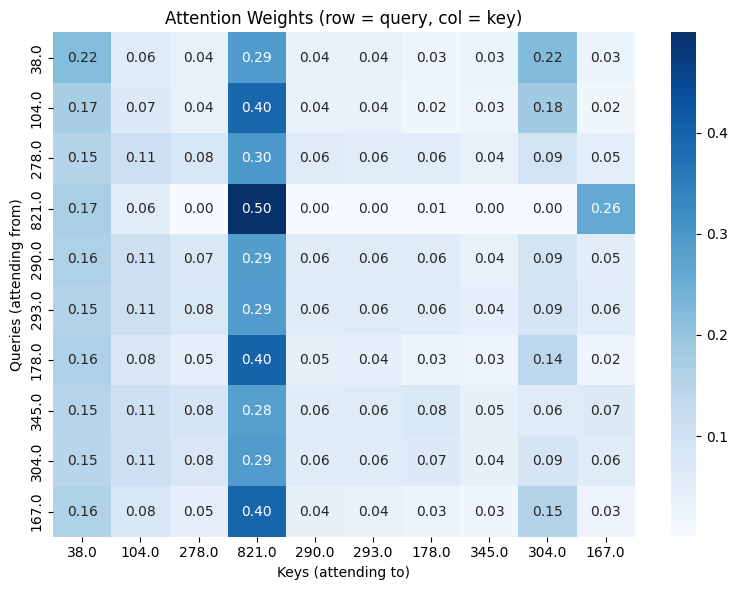

Input sequence: [38.0, 104.0, 278.0, 821.0, 290.0, 293.0, 178.0, 345.0, 304.0, 167.0]
True ranks: [0, 1, 4, 9, 5, 6, 3, 8, 7, 2]


In [133]:
import matplotlib.pyplot as plt
import seaborn as sns

# Hook to extract attention weights
attention_weights = []


# Better approach - run one sample manually
model_encoder.eval()
sample_values, sample_ranks = next(iter(testloader))
sample_values = sample_values[:1].float()  # just one sequence

# Normalize same as forward
x = sample_values
x = (x - x.mean(dim=1, keepdim=True)) / (x.std(dim=1, keepdim=True) + 1e-8)
x = x.unsqueeze(-1)
x = model_encoder.input_proj(x)
positions = torch.arange(10, device=x.device)
x = x + model_encoder.pos_encoding(positions)

attn_output, attn_weights_raw = model_encoder.layers[0].attention(x)
attn_weights = attn_weights_raw.mean(dim=1).squeeze(0).detach().numpy()  # average across heads → (10, 10)

plt.figure(figsize=(8, 6))
sns.heatmap(attn_weights, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=[f'{v:.1f}' for v in sample_values[0].tolist()],
            yticklabels=[f'{v:.1f}' for v in sample_values[0].tolist()])
plt.title('Attention Weights (row = query, col = key)')
plt.xlabel('Keys (attending to)')
plt.ylabel('Queries (attending from)')
plt.tight_layout()
plt.show()

print(f"Input sequence: {sample_values[0].tolist()}")
print(f"True ranks: {sample_ranks[0].tolist()}")

#### lets write a predict function to predict a single sequence we give as input to check the model on different examples 

In [134]:
def predict (sequence , model):
    #go to eval mode
    model.eval()

    #now we need to convert the tensor to (1,10) so that it works as if batch_size = 1 in the code 
    x = torch.tensor(sequence, dtype= torch.float32 ).unsqueeze(0) # converted to (1,10)

    with torch.no_grad():
        output = model(x)
        pred = output.argmax(dim = 1).squeeze(0) # converted from (1,10,10) to (1,10) by argmax then to (10,)

    print(f"Input: {sequence}")
    print(f"pred: {pred.tolist()}") # this is better than this list(pred) => gives [tensor(6), tensor(6), ....]

    #this does not work
    #True_ranks = np.argsort(sequence)    
    #print(f"True: {True_ranks}")

    #googled ----
    #1. Get unique values in sorted order and their inverse indices  (indices of the unique list formed not the original list )
    values, inverse_indices = torch.unique(torch.tensor(sequence), return_inverse=True)
    # 2. Convert to a clean list of ranks
    ranks = inverse_indices.tolist()

    print(f"True ranks: {ranks}")

#### i need to submit the trained weights 

In [135]:
#took help of ai for code 

torch.save(model_encoder.state_dict(), 'transformer_encoder.pth')
torch.save(model_MLP.state_dict(), 'mlp_model.pth')
torch.save(model_RNN.state_dict(), 'rnn_model.pth')

## Experiments 

#### checking the exact sequence accuracy (the model was trained on token based accuracy)

In [136]:
# this is written to test to see what percent time the model predicts all the inputs correct 
def exact_sequence_accuracy(model, dataloader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for values, ranks in dataloader:
            values = values.float()
            ranks = ranks.long()
            output = model(values)
            preds = output.argmax(dim=1)  # (batch, 10)

            # sequence is correct only if ALL 10 positions are correct
            correct += (preds == ranks).all(dim=1).sum().item()
            total += ranks.size(0)
    acc = correct / total
    print(f"Exact Sequence Accuracy: {acc:.4f}")
    return acc

exact_sequence_accuracy(model_encoder, testloader)
exact_sequence_accuracy(model_MLP, testloader)
exact_sequence_accuracy(model_RNN, testloader)

#only the encoder was able to at lest get some value :)

Exact Sequence Accuracy: 0.7007
Exact Sequence Accuracy: 0.0000
Exact Sequence Accuracy: 0.0000


0.0

#### now lets test some inputs from me (for which the predict function is made)

In [137]:

sequences = [
    [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],       # ascending order
    [1000, 900, 800, 700, 600, 500, 400, 300, 200, 100],  # descending large
    [5, 5, 5, 5, 5, 5, 5, 5, 5, 5],         #all same
    [1000, 1, 0, 100000, 2, 3, 87, 6, 100, 50]  #huge range
]


for seq in sequences:
    print(f"\n--- MLP ---")
    predict(seq, model_MLP)



--- MLP ---
Input: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
pred: [0, 2, 3, 3, 3, 6, 7, 7, 8, 8]
True ranks: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

--- MLP ---
Input: [1000, 900, 800, 700, 600, 500, 400, 300, 200, 100]
pred: [9, 8, 9, 7, 4, 4, 3, 1, 0, 0]
True ranks: [9, 8, 7, 6, 5, 4, 3, 2, 1, 0]

--- MLP ---
Input: [5, 5, 5, 5, 5, 5, 5, 5, 5, 5]
pred: [5, 5, 3, 7, 5, 6, 3, 7, 6, 5]
True ranks: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

--- MLP ---
Input: [1000, 1, 0, 100000, 2, 3, 87, 6, 100, 50]
pred: [6, 6, 6, 7, 6, 4, 5, 5, 6, 6]
True ranks: [8, 1, 0, 9, 2, 3, 6, 4, 7, 5]


In [138]:
# for RNN
for seq in sequences:
    print(f"\n--- RNN ---")
    predict(seq, model_RNN)



--- RNN ---
Input: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
pred: [0, 3, 3, 7, 8, 2, 5, 9, 8, 8]
True ranks: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

--- RNN ---
Input: [1000, 900, 800, 700, 600, 500, 400, 300, 200, 100]
pred: [9, 9, 6, 6, 5, 4, 2, 2, 1, 7]
True ranks: [9, 8, 7, 6, 5, 4, 3, 2, 1, 0]

--- RNN ---
Input: [5, 5, 5, 5, 5, 5, 5, 5, 5, 5]
pred: [0, 3, 3, 7, 8, 3, 5, 9, 9, 8]
True ranks: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

--- RNN ---
Input: [1000, 1, 0, 100000, 2, 3, 87, 6, 100, 50]
pred: [9, 0, 1, 9, 7, 4, 4, 5, 5, 7]
True ranks: [8, 1, 0, 9, 2, 3, 6, 4, 7, 5]


In [139]:
#encoder 
for seq in sequences:
    print(f"\n--- encoder---")
    predict(seq, model_encoder)



--- encoder---
Input: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
pred: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
True ranks: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

--- encoder---
Input: [1000, 900, 800, 700, 600, 500, 400, 300, 200, 100]
pred: [9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
True ranks: [9, 8, 7, 6, 5, 4, 3, 2, 1, 0]

--- encoder---
Input: [5, 5, 5, 5, 5, 5, 5, 5, 5, 5]
pred: [9, 9, 9, 9, 9, 9, 9, 9, 9, 9]
True ranks: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

--- encoder---
Input: [1000, 1, 0, 100000, 2, 3, 87, 6, 100, 50]
pred: [3, 4, 4, 9, 4, 9, 9, 9, 4, 4]
True ranks: [8, 1, 0, 9, 2, 3, 6, 4, 7, 5]


#### now lets visualize the attention per head

defining a function (took help of ai)

In [140]:
def visualize_attention(model, sample_values, per_head=False):
    model.eval()
    x = sample_values[:1].float()
    x = (x - x.mean(dim=1, keepdim=True)) / (x.std(dim=1, keepdim=True) + 1e-8)
    x = x.unsqueeze(-1)
    x = model.input_proj(x)
    positions = torch.arange(10, device=x.device)
    x = x + model.pos_encoding(positions)
    
    _, attn_weights_raw = model.layers[0].attention(x)
    # attn_weights_raw shape: (1, nhead, 10, 10)
    
    labels = [f'{v:.0f}' for v in sample_values[0].tolist()]
    
    if per_head:
        nhead = attn_weights_raw.shape[1]
        fig, axes = plt.subplots(1, nhead, figsize=(5*nhead, 5))
        for head in range(nhead):
            head_weights = attn_weights_raw[0, head].detach().numpy()
            sns.heatmap(head_weights, ax=axes[head], cmap='Blues', annot=True, fmt='.2f',
                        xticklabels=labels, yticklabels=labels)
            axes[head].set_title(f'Head {head}')
        plt.suptitle('Per-Head Attention Weights')
    else:
        avg_weights = attn_weights_raw.mean(dim=1).squeeze(0).detach().numpy()
        plt.figure(figsize=(8, 6))
        sns.heatmap(avg_weights, annot=True, fmt='.2f', cmap='Blues',
                    xticklabels=labels, yticklabels=labels)
        plt.title('Attention Weights (averaged across heads)')
    
    plt.tight_layout()
    plt.show()

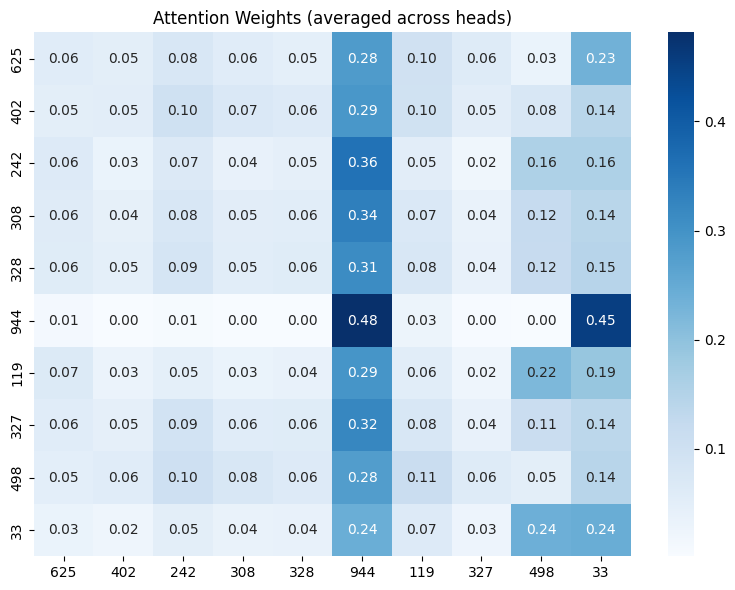

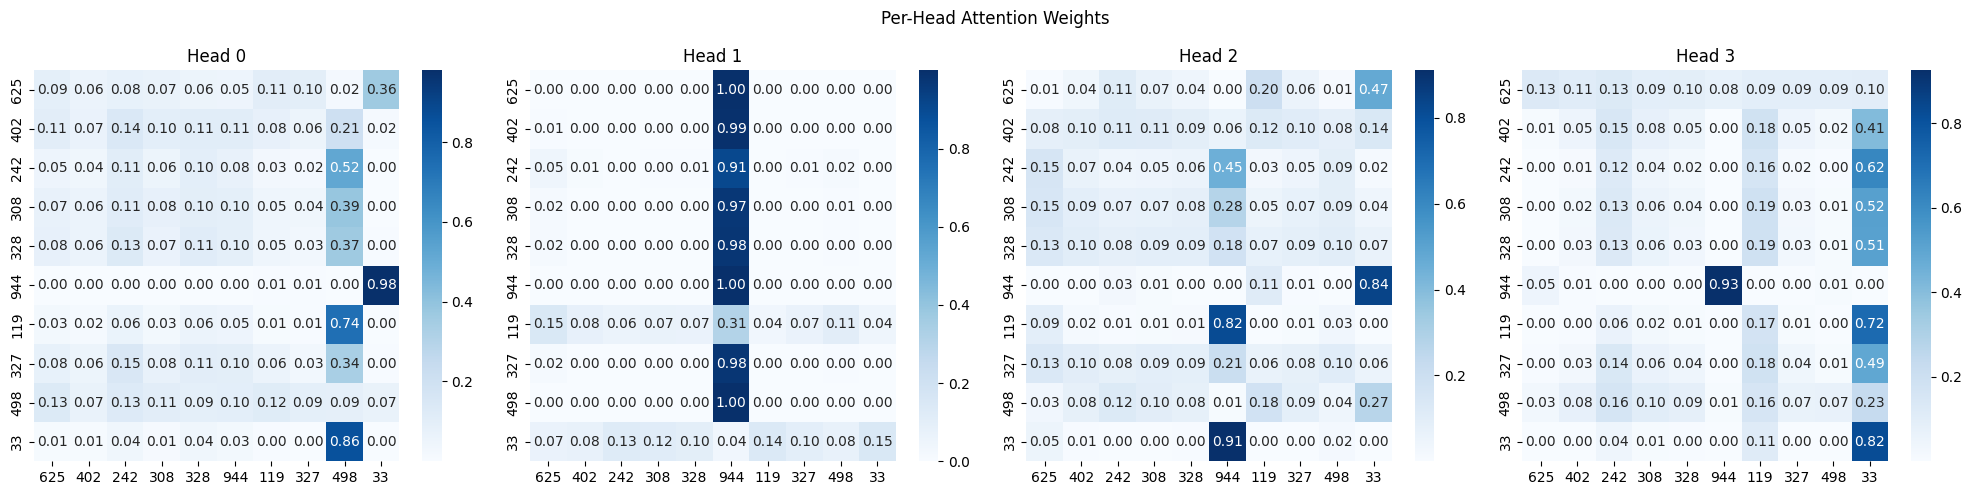

In [141]:
sample_values, sample_ranks = next(iter(testloader))

visualize_attention(model_encoder, sample_values)              # averaged
visualize_attention(model_encoder, sample_values, per_head=True)  # per head

#### now lets check the encoder accuracy on different number of encoder layers 

In [142]:

for num_layers in [1, 2, 4]:
    print(f"\n---------- Transformer with {num_layers} layer(s) -----------------------")
    m = TransformerEncoder(num_layers=num_layers)
    run(m, trainloader, validationloader)
    check_acc(m, testloader)


---------- Transformer with 1 layer(s) -----------------------
Epoch 1 | Loss: 1.3415 | Val Acc: 0.5774
Epoch 2 | Loss: 0.8869 | Val Acc: 0.6211
Epoch 3 | Loss: 0.8313 | Val Acc: 0.6395
Epoch 4 | Loss: 0.7962 | Val Acc: 0.6463
Epoch 5 | Loss: 0.7727 | Val Acc: 0.6582
Epoch 6 | Loss: 0.7585 | Val Acc: 0.6575
Epoch 7 | Loss: 0.7469 | Val Acc: 0.6675
Epoch 8 | Loss: 0.7430 | Val Acc: 0.6611
Epoch 9 | Loss: 0.7377 | Val Acc: 0.6658
Epoch 10 | Loss: 0.7345 | Val Acc: 0.6661
Epoch 11 | Loss: 0.7354 | Val Acc: 0.6733
Epoch 12 | Loss: 0.7278 | Val Acc: 0.6682
Epoch 13 | Loss: 0.7280 | Val Acc: 0.6687
Epoch 14 | Loss: 0.7274 | Val Acc: 0.6725
Epoch 15 | Loss: 0.7233 | Val Acc: 0.6749
Epoch 16 | Loss: 0.7212 | Val Acc: 0.6716
Epoch 17 | Loss: 0.7196 | Val Acc: 0.6723
Epoch 18 | Loss: 0.7152 | Val Acc: 0.6748
Epoch 19 | Loss: 0.7165 | Val Acc: 0.6744
Epoch 20 | Loss: 0.7183 | Val Acc: 0.6693
Test Accuracy: 0.6699

---------- Transformer with 2 layer(s) -----------------------
Epoch 1 | Loss: 1.1